## Open3D Geometry Tutorial

In [1]:
import open3d as o3d
import numpy as np

In [ ]:
import open3d as o3d
import numpy as np


print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)
print(pcd)
print(np.asarray(pcd.points))
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

In [ ]:

import open3d as o3d
import numpy as np


print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

print("Downsample the point cloud with a voxel of 0.05")
downpcd = pcd.voxel_down_sample(voxel_size=0.05)
o3d.visualization.draw_geometries([downpcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

In [1]:


import open3d as o3d
import numpy as np


print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

print("Downsample the point cloud with a voxel of 0.05")
downpcd = pcd.voxel_down_sample(voxel_size=0.05)


print("Recompute the normal of the downsampled point cloud")
downpcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
# o3d.visualization.draw_geometries([downpcd],
#                                   zoom=0.3412,
#                                   front=[0.4257, -0.2125, -0.8795],
#                                   lookat=[2.6172, 2.0475, 1.532],
#                                   up=[-0.0694, -0.9768, 0.2024],
#                                   point_show_normal=True)

Load a ply point cloud, print it, and render it
Downsample the point cloud with a voxel of 0.05
Recompute the normal of the downsampled point cloud


In [2]:
print("Print a normal vector of the 0th point")
print(downpcd.normals[0])

Print a normal vector of the 0th point
[-0.27566603 -0.89197839 -0.35830543]


In [ ]:
help(pcd)

In [4]:


print("Load a polygon volume and use it to crop the original point cloud")
demo_crop_data = o3d.data.DemoCropPointCloud()
pcd = o3d.io.read_point_cloud(demo_crop_data.point_cloud_path)
vol = o3d.visualization.read_selection_polygon_volume(demo_crop_data.cropped_json_path)
chair = vol.crop_point_cloud(pcd)
o3d.visualization.draw_geometries([chair],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])

Load a polygon volume and use it to crop the original point cloud
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/DemoCropPointCloud.zip
[Open3D INFO] Downloaded to /Users/bisalgt/open3d_data/download/DemoCropPointCloud/DemoCropPointCloud.zip
[Open3D INFO] Created directory /Users/bisalgt/open3d_data/extract/DemoCropPointCloud.
[Open3D INFO] Extracting /Users/bisalgt/open3d_data/download/DemoCropPointCloud/DemoCropPointCloud.zip.
[Open3D INFO] Extracted to /Users/bisalgt/open3d_data/extract/DemoCropPointCloud.
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


In [ ]:
pcd_point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(pcd_point_cloud.path)

plane_model, inliers = pcd.segment_plane(distance_threshold=0.01,
                                         ransac_n=3,
                                         num_iterations=1000)
[a, b, c, d] = plane_model
print(f"Plane equation: {a:.2f}x + {b:.2f}y + {c:.2f}z + {d:.2f} = 0")

inlier_cloud = pcd.select_by_index(inliers)
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud = pcd.select_by_index(inliers, invert=True)
o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud],
                                  zoom=0.8,
                                  front=[-0.4999, -0.1659, -0.8499],
                                  lookat=[2.1813, 2.0619, 2.0999],
                                  up=[0.1204, -0.9852, 0.1215])

In [ ]:
import numpy as np
import open3d as o3d


print("Convert mesh to a point cloud and estimate dimensions")
armadillo = o3d.data.ArmadilloMesh()
mesh = o3d.io.read_triangle_mesh(armadillo.path)
mesh.compute_vertex_normals()

pcd = mesh.sample_points_poisson_disk(5000)
diameter = np.linalg.norm(
    np.asarray(pcd.get_max_bound()) - np.asarray(pcd.get_min_bound()))
o3d.visualization.draw_geometries([pcd])

Convert mesh to a point cloud and estimate dimensions
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/ArmadilloMesh.ply
[Open3D INFO] Downloaded to /Users/bisalgt/open3d_data/download/ArmadilloMesh/ArmadilloMesh.ply


In [ ]:
import numpy as np
import open3d as o3d



print("Convert mesh to a point cloud and estimate dimensions")
armadillo = o3d.data.ArmadilloMesh()
mesh = o3d.io.read_triangle_mesh(armadillo.path)
mesh.compute_vertex_normals()

pcd = mesh.sample_points_poisson_disk(5000)
diameter = np.linalg.norm(
    np.asarray(pcd.get_max_bound()) - np.asarray(pcd.get_min_bound()))


print("Define parameters used for hidden_point_removal")
camera = [0, 0, diameter]
radius = diameter * 100

print("Get all points that are visible from given view point")
_, pt_map = pcd.hidden_point_removal(camera, radius)

print("Visualize result")
pcd = pcd.select_by_index(pt_map)
o3d.visualization.draw_geometries([pcd])

#### loading the pointcloud data and visualizing

In [ ]:
import open3d as o3d
import numpy as np
import pandas as pd

# Load point cloud data from CSV file
data = pd.read_csv('kitti.csv')
points = data.iloc[:, 0:3].values

# Convert point cloud data to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Visualize point cloud data
o3d.visualization.draw_geometries([pcd])


### loading the point cloud data with intensity

In [11]:
import open3d as o3d
import numpy as np
import pandas as pd

# Load point cloud data from CSV file
data = pd.read_csv('kitti.csv', delimiter=',', skiprows=1, header=None)
points = data.iloc[:, 0:3].values
intensity = data.iloc[:, 3].values

# Convert point cloud data to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
# pcd.colors = o3d.utility.Vector3dVector(intensity.reshape(-1, 1) / 255.0)

# Visualize point cloud data
# o3d.visualization.draw_geometries([pcd])


In [12]:
pcd.colors

std::vector<Eigen::Vector3d> with 0 elements.
Use numpy.asarray() to access data.

In [13]:
pcd.points

std::vector<Eigen::Vector3d> with 123810 elements.
Use numpy.asarray() to access data.

In [14]:
pcd.has_colors()

False

In [15]:
points

array([[48.84137344, 12.2466259 ,  1.91378045],
       [51.42350388, 25.06738853,  2.1465559 ],
       [51.34181213, 25.22836304,  2.14655137],
       ...,
       [ 3.78389525, -1.39968419, -1.72842097],
       [ 3.79913568, -1.39168596, -1.73442638],
       [ 3.82482767, -1.39568532, -1.74642861]])

In [16]:
points.shape

(123810, 3)

In [17]:
intensity

array([ 1.91378045,  2.1465559 ,  2.14655137, ..., -1.72842097,
       -1.73442638, -1.74642861])

In [18]:
intensity.shape

(123810,)

In [19]:
intensity.max()

2.9002599716186523

In [20]:
intensity.min()

-25.742982864379883

In [15]:
reshaped_intensity = intensity.reshape(-1, 1)

In [16]:
intensity.shape

(123810,)

In [18]:
reshaped_intensity.shape

(123810, 1)

In [19]:
reshaped_intensity

array([[ 1.91378045],
       [ 2.1465559 ],
       [ 2.14655137],
       ...,
       [-1.72842097],
       [-1.73442638],
       [-1.74642861]])

In [20]:
data.head()

,0,1,2,3
0,48.841373,12.246626,1.913780,1.913780
1,51.423504,25.067389,2.146556,2.146556
2,51.341812,25.228363,2.146551,2.146551
3,43.935711,22.546873,1.881482,1.881482
4,43.719013,22.609865,1.876476,1.876476


In [21]:
data = pd.read_csv('kitti.csv', delimiter=',')
data.head()

,x,y,z,i
0,48.841373,12.246626,1.913780,1.913780
1,51.423504,25.067389,2.146556,2.146556
2,51.341812,25.228363,2.146551,2.146551
3,43.935711,22.546873,1.881482,1.881482
4,43.719013,22.609865,1.876476,1.876476


In [22]:
data.iloc[:,1].max()

68.35206604003906

In [23]:
data.iloc[:, 1].min()

-43.59238052368164

In [4]:
intensity

array([ 1.91378045,  2.1465559 ,  2.14655137, ..., -1.72842097,
       -1.73442638, -1.74642861])

In [5]:
intensity.max()

2.9002599716186523

In [6]:
intensity.min()

-25.742982864379883

In [21]:
normalized_intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min())

In [22]:
normalized_intensity

array([0.96555978, 0.9736865 , 0.97368634, ..., 0.83840234, 0.83819268,
       0.83777366])

In [23]:
normalized_intensity.max()

1.0

In [24]:
normalized_intensity.min()

0.0

In [6]:
pcd

PointCloud with 123810 points.

In [7]:
reshaped_normalized_intensity = normalized_intensity.reshape(-1, 1)

In [8]:
reshaped_normalized_intensity.shape

(123810, 1)

In [43]:
pcd.colors = reshaped_normalized_intensity

TypeError: (): incompatible function arguments. The following argument types are supported:
    1. (self: open3d.cpu.pybind.geometry.PointCloud, arg0: open3d.cpu.pybind.utility.Vector3dVector) -> None

Invoked with: PointCloud with 123810 points., array([[0.96555978],
       [0.9736865 ],
       [0.97368634],
       ...,
       [0.83840234],
       [0.83819268],
       [0.83777366]])

In [ ]:
pcd.colors = o3d.utility.Vector3dVector(reshaped_normalized_intensity)

In [ ]:

o3d.utility.Vector3dVector(reshaped_normalized_intensity)

In [25]:
normalized_intensity.shape

(123810,)

In [26]:
normalized_intensity

array([0.96555978, 0.9736865 , 0.97368634, ..., 0.83840234, 0.83819268,
       0.83777366])

In [28]:
intensity_3d = np.stack((normalized_intensity,)*3, axis=-1)

In [29]:
intensity_3d

array([[0.96555978, 0.96555978, 0.96555978],
       [0.9736865 , 0.9736865 , 0.9736865 ],
       [0.97368634, 0.97368634, 0.97368634],
       ...,
       [0.83840234, 0.83840234, 0.83840234],
       [0.83819268, 0.83819268, 0.83819268],
       [0.83777366, 0.83777366, 0.83777366]])

In [30]:
intensity_3d.shape

(123810, 3)

In [31]:
colors = o3d.utility.Vector3dVector(intensity_3d)

In [32]:
pcd

PointCloud with 123810 points.

In [33]:
pcd.colors = colors

In [ ]:
o3d.visualization.draw_geometries([pcd])

## Visualizing point cloud with normalized intensity, points value in range between 0 and 1. Black and White Image with varying intensity

In [1]:

import open3d as o3d
import numpy as np
import pandas as pd

# Load point cloud data from CSV file
data = pd.read_csv('kitti.csv', delimiter=',', skiprows=1, header=None)
points = data.iloc[:, 0:3].values
intensity = data.iloc[:, 3].values

# Convert point cloud data to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Normalizing the intensity value between [0, 1]
normalized_intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min())

# Creating 3d points using np.stack
intensity_3d = np.stack((normalized_intensity,)*3, axis=-1)

# Converting the np.array to pontcloud format
colors = o3d.utility.Vector3dVector(intensity_3d)

# Setting the color of pcd
pcd.colors = colors


# Visualizing the point cloud
# o3d.visualization.draw_geometries([pcd])
o3d.visualization.draw_geometries_with_editing([pcd], window_name='Visualize the kitti data', width=800, height=600)



[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


## Experimenting with JVisualizer -- Not Working

In [3]:
import numpy as np
import open3d as o3d
from open3d import JVisualizer

points = (np.random.rand(1000, 3) - 0.5) / 4
colors = np.random.rand(1000, 3)

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

visualizer = JVisualizer()
visualizer.add_geometry(pcd)
visualizer.show()

ImportError: cannot import name 'JVisualizer' from 'open3d' (/Users/bisalgt/Projects/playground/open3d_pointcloud/env/lib/python3.10/site-packages/open3d/__init__.py)

## Changing the colors to [0, G, 0]

In [4]:
normalized_intensity.shape

(123810,)

In [6]:
np.zeros(normalized_intensity.shape)

array([0., 0., 0., ..., 0., 0., 0.])

In [8]:
np.stack((np.zeros(normalized_intensity.shape),)*3).shape

(3, 123810)

In [9]:
np.stack((np.zeros(normalized_intensity.shape),)*3, axis=-1).shape

(123810, 3)

In [10]:
np.stack((normalized_intensity, np.zeros(normalized_intensity.shape))).shape

(2, 123810)

In [11]:

import open3d as o3d
import numpy as np
import pandas as pd

# Load point cloud data from CSV file
data = pd.read_csv('kitti.csv', delimiter=',', skiprows=1, header=None)
points = data.iloc[:, 0:3].values
intensity = data.iloc[:, 3].values

# Convert point cloud data to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Normalizing the intensity value between [0, 1]
normalized_intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min())

# Creating Color stack
r_color = np.zeros(normalized_intensity.shape)
g_color = normalized_intensity
b_color = np.zeros(normalized_intensity.shape)


# Creating 3d points using np.stack
intensity_3d = np.stack((r_color, g_color, b_color), axis=-1)

# Converting the np.array to pontcloud format
colors = o3d.utility.Vector3dVector(intensity_3d)

# Setting the color of pcd
pcd.colors = colors


# Visualizing the point cloud
# o3d.visualization.draw_geometries([pcd])
o3d.visualization.draw_geometries_with_editing([pcd], window_name='Visualize the kitti data')



[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


## Compute Covariance Matrices, Eigenvalues and Surface Variation

In [68]:

import open3d as o3d
import numpy as np
import pandas as pd

# Load point cloud data from CSV file
data = pd.read_csv('kitti.csv', delimiter=',', skiprows=1, header=None)
points = data.iloc[:, 0:3].values
intensity = data.iloc[:, 3].values

# Convert point cloud data to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Normalizing the intensity value between [0, 1]
normalized_intensity = (intensity - intensity.min()) / (intensity.max() - intensity.min())

# Creating Color stack
r_color = np.zeros(normalized_intensity.shape)
g_color = normalized_intensity
b_color = np.zeros(normalized_intensity.shape)


# Creating 3d points using np.stack
intensity_3d = np.stack((r_color, g_color, b_color), axis=-1)

# Converting the np.array to pontcloud format
colors = o3d.utility.Vector3dVector(intensity_3d)

# Setting the color of pcd
pcd.colors = colors


# Visualizing the point cloud
o3d.visualization.draw_geometries([pcd])
# o3d.visualization.draw_geometries_with_editing([pcd], window_name='Visualize the kitti data')



[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display
[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


In [2]:
pcd

PointCloud with 123810 points.

In [3]:
pcd.has_colors

<bound method PyCapsule.has_colors of PointCloud with 123810 points.>

In [6]:
pcd.estimate_point_covariances()

TypeError: estimate_point_covariances(): incompatible function arguments. The following argument types are supported:
    1. (input: open3d.cpu.pybind.geometry.PointCloud, search_param: open3d.cpu.pybind.geometry.KDTreeSearchParam = KDTreeSearchParamKNN with knn = 30) -> open3d.cpu.pybind.utility.Matrix3dVector

Invoked with: 

In [8]:
help(pcd.estimate_point_covariances)

Help on built-in function estimate_point_covariances in module open3d.cpu.pybind.geometry:

estimate_point_covariances(...) method of builtins.PyCapsule instance
    estimate_point_covariances(input, search_param=KDTreeSearchParamKNN with knn = 30)
    Static function to compute the covariance matrix for each point in the given point cloud, doesn't change the input
    
    Args:
        input (open3d.geometry.PointCloud): The input point cloud.
        search_param (open3d.geometry.KDTreeSearchParam, optional, default=KDTreeSearchParamKNN with knn = 30): The KDTree search parameters for neighborhood search.
    
    Returns:
        open3d.utility.Matrix3dVector



In [9]:
pcd

PointCloud with 123810 points.

In [10]:
type(pcd)

open3d.cpu.pybind.geometry.PointCloud

In [11]:
pcd.estimate_covariances()

In [13]:
pcd.has_covariances()

True

In [14]:
pcd.covariances

std::vector<Eigen::Matrix3d> with 123810 elements.
Use numpy.asarray() to access data.

In [15]:
covariances_mtx = np.asarray(pcd.covariances)

In [17]:
covariances_mtx.shape

(123810, 3, 3)

In [18]:

a = covariances_mtx[0]

In [19]:
a

array([[ 0.26193899, -0.01886514, -0.10157508],
       [-0.01886514,  0.0310235 , -0.02833803],
       [-0.10157508, -0.02833803,  0.58395394]])

In [20]:

a.shape

(3, 3)

In [21]:
np.linalg.eigh(a)

(array([0.02691418, 0.23585398, 0.61414826]),
 array([[-0.11005113,  0.95511527, -0.27503376],
        [-0.99142219, -0.12511612, -0.03778875],
        [-0.07050377,  0.26851588,  0.96069165]]))

In [22]:
np.linalg.eig(a)

(array([0.61414826, 0.23585398, 0.02691418]),
 array([[ 0.27503376, -0.95511527, -0.11005113],
        [ 0.03778875,  0.12511612, -0.99142219],
        [-0.96069165, -0.26851588, -0.07050377]]))

In [23]:
b = covariances_mtx[:5]

In [24]:
b

array([[[ 0.26193899, -0.01886514, -0.10157508],
        [-0.01886514,  0.0310235 , -0.02833803],
        [-0.10157508, -0.02833803,  0.58395394]],

       [[ 0.73789365,  0.24481664,  0.28301602],
        [ 0.24481664,  0.50965586,  0.16000977],
        [ 0.28301602,  0.16000977,  0.22961318]],

       [[ 0.74366664,  0.22016609,  0.29874933],
        [ 0.22016609,  0.48961881,  0.15192714],
        [ 0.29874933,  0.15192714,  0.24461645]],

       [[ 0.25486625, -0.0011776 , -0.07858776],
        [-0.0011776 ,  0.17389221,  0.02963832],
        [-0.07858776,  0.02963832,  0.13430891]],

       [[ 0.23112214, -0.00364825, -0.04928415],
        [-0.00364825,  0.19045522,  0.04455283],
        [-0.04928415,  0.04455283,  0.15122647]]])

In [25]:
b.shape

(5, 3, 3)

In [27]:
eig_b = np.linalg.eig(b)

In [28]:
eig_b

(array([[0.61414826, 0.23585398, 0.02691418],
        [1.02626798, 0.3545832 , 0.09631151],
        [1.01610784, 0.36340002, 0.09839404],
        [0.29533116, 0.08758603, 0.18015018],
        [0.10866552, 0.2628432 , 0.20129512]]),
 array([[[ 0.27503376, -0.95511527, -0.11005113],
         [ 0.03778875,  0.12511612, -0.99142219],
         [-0.96069165, -0.26851588, -0.07050377]],
 
        [[-0.78606088, -0.5092147 , -0.35044069],
         [-0.48944628,  0.85898283, -0.15030248],
         [-0.37755877, -0.05337499,  0.92444604]],
 
        [[-0.79972924, -0.46917006, -0.37458323],
         [-0.44932725,  0.88154736, -0.14484227],
         [-0.39816851, -0.05247586,  0.91581009]],
 
        [[-0.88345709,  0.40499251, -0.23555176],
         [ 0.11915207, -0.29201538, -0.94896249],
         [ 0.45310744,  0.86643412, -0.20972736]],
 
        [[ 0.32366343,  0.80141983, -0.50295948],
         [-0.44143471, -0.34227129, -0.82944907],
         [ 0.83688553, -0.4904861 , -0.24299383]]]))

In [29]:
eig_b

AttributeError: 'tuple' object has no attribute 'shape'

In [31]:
eigenvalues = np.linalg.eig(covariances_mtx)[0]

In [32]:
eigenvalues.shape

(123810, 3)

In [34]:
def find_surface_variation(arr):
    return arr.min()/(arr.sum())
    

np.apply_along_axis(find_surface_variation, 1, eig_b[0])

array([0.03069184, 0.06520034, 0.06657684, 0.1555516 , 0.18970809])

In [35]:
eig_b[0]

array([[0.61414826, 0.23585398, 0.02691418],
       [1.02626798, 0.3545832 , 0.09631151],
       [1.01610784, 0.36340002, 0.09839404],
       [0.29533116, 0.08758603, 0.18015018],
       [0.10866552, 0.2628432 , 0.20129512]])

In [43]:
arr = eig_b[0][1]

In [44]:
arr

array([1.02626798, 0.3545832 , 0.09631151])

In [45]:
arr.min()/(arr.sum())

0.06520034183127524

In [46]:
arr.min()

0.09631151263027414

In [42]:
(0.61414826 + 0.23585398 + 0.02691418)

0.87691642

In [47]:
arr.sum()

1.4771626946298544

In [48]:
surface_variation = np.apply_along_axis(find_surface_variation, 1, eigenvalues)

In [49]:
surface_variation.shape

(123810,)

In [50]:
surface_variation.max()

0.3178910363617718

In [51]:
surface_variation.min()

2.549583021708197e-08

In [60]:
normalized_surface_variation = (surface_variation - surface_variation.min())/(surface_variation.max() - surface_variation.min())

In [61]:
normalized_surface_variation

array([0.09654824, 0.20510274, 0.20943283, ..., 0.01385651, 0.01331454,
       0.01406731])

In [62]:
normalized_surface_variation.shape

(123810,)

In [56]:
normalized_surface_variation = normalized_surface_variation.reshape(-1, 1)

In [57]:
normalized_surface_variation.shape

(123810, 1)

In [58]:
rgb_value = np.stack((np.zeros(normalized_surface_variation.shape), normalized_surface_variation, np.zeros(normalized_surface_variation.shape)))

In [59]:
rgb_value.shape

(3, 123810, 1)

In [63]:

def get_rgb_color_from_intensity(normalized_intensity):
    # Normalized Intensity is used
    
    # Creating Color stack
    r_color = np.zeros(normalized_intensity.shape)
    g_color = normalized_intensity
    b_color = np.zeros(normalized_intensity.shape)

    # Creating 3d points using np.stack
    intensity_3d = np.stack((r_color, g_color, b_color), axis=-1)
    
    return intensity_3d

In [64]:
intensity_3d = get_rgb_color_from_intensity(normalized_surface_variation)

In [65]:
normalized_surface_variation.shape

(123810,)

In [66]:
intensity_3d.shape

(123810, 3)

In [67]:
# Converting the np.array to pontcloud format
colors = o3d.utility.Vector3dVector(intensity_3d)

# Setting the color of pcd
pcd.colors = colors

# Calculating the surface variation and plotting as intensity.

In [1]:

import open3d as o3d
import numpy as np
import pandas as pd


def find_surface_variation(arr):
    return arr.min()/(arr.sum())
    


def get_rgb_color_from_intensity(normalized_intensity):
    # Normalized Intensity is used
    # Creating Color stack
    r_color = np.zeros(normalized_intensity.shape)
    g_color = normalized_intensity
    b_color = np.zeros(normalized_intensity.shape)
    # Creating 3d points using np.stack
    intensity_3d = np.stack((r_color, g_color, b_color), axis=-1)
    return intensity_3d







# Load point cloud data from CSV file
data = pd.read_csv('kitti.csv', delimiter=',', skiprows=1, header=None)
points = data.iloc[:, 0:3].values

# Convert point cloud data to Open3D format
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)


# Compute Covariances and Eigenvalues
# These will be used to find the surface_variation

# Covariances will be estimated and placed at pcd.covariances
# can be checked using pcd.has_covariances
pcd.estimate_covariances()

#Convert Pcd data type to np array.
covariances_mtx = np.asarray(pcd.covariances)

# gives eigenvalues and eigenvectors
eigenvalues, _ = np.linalg.eig(covariances_mtx)


# Find Surface Variation From eigenvalues
surface_variation = np.apply_along_axis(find_surface_variation, 1, eigenvalues)

# The value is not between [0, 1] so we need to normalize the surface variation
normalized_surface_variation = (surface_variation - surface_variation.min())/(surface_variation.max() - surface_variation.min())


# Getting the intensity in 3x1 for each points
intensity_3d = get_rgb_color_from_intensity(normalized_surface_variation)

# Converting the np.array to pontcloud format
colors = o3d.utility.Vector3dVector(intensity_3d)

# Setting the color of pcd
pcd.colors = colors

# Visualizing the point cloud
o3d.visualization.draw_geometries([pcd])
# o3d.visualization.draw_geometries_with_editing([pcd], window_name='Visualize the kitti data')



[Open3D WARNING] GLFW Error: Cocoa: Failed to find service port for display


In [2]:
normalized_surface_variation

array([0.09654824, 0.20510274, 0.20943283, ..., 0.01385651, 0.01331454,
       0.01406731])

In [3]:
std_dev = np.std(normalized_surface_variation)

In [4]:
mean = np.mean(std_dev)

In [5]:
std_dev.shape

()

In [6]:
mean.shape

()

In [18]:
reshaped_normalized_surface_variation = normalized_surface_variation.flatten()

In [19]:
std_dev = np.std(reshaped_normalized_surface_variation)
mean = np.mean(reshaped_normalized_surface_variation)

In [21]:
std_dev

0.1891368981989325

In [22]:
reshaped_normalized_surface_variation.ndim

1

In [23]:
mean

0.12011319714587838

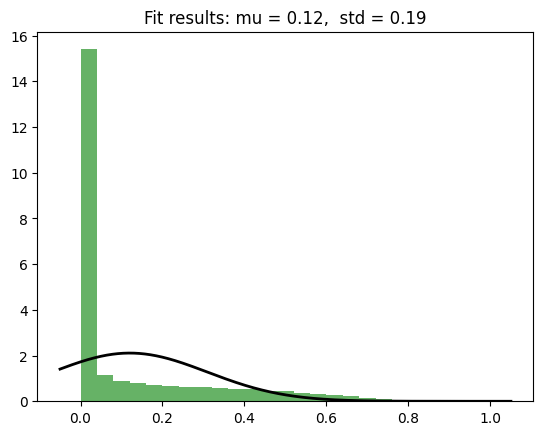

In [28]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


# Generate some data for this demonstration.
data = reshaped_normalized_surface_variation

# Fit a normal distribution to the data:
mu, std = norm.fit(data)

# Plot the histogram.
plt.hist(data, bins=25, density=True, alpha=0.6, color='g')

# Plot the PDF.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 1000)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
plt.title(title)

plt.show()